In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print("Всё работает!")

pandas: 2.3.3
numpy: 2.2.6
Всё работает!


# EDA: дефицитные анемии

**Датасет:** `deficiency_anemia.csv`
**Размер:** 840 пациентов, 48 признаков
**Задача:** мультиклассовая классификация `anemia_class` (12 классов)

## План
1. Загрузка и первичный осмотр
2. Проверка пропусков
3. Распределение классов
4. Распределение ключевых признаков
5. Проверка целевых переменных
6. Выводы

In [3]:
# ============ ИМПОРТЫ И НАСТРОЙКИ ============
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Настройки
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Графики
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Seed
RANDOM_STATE = 42

print("Настройки применены")

Настройки применены


In [4]:
# ============ ЗАГРУЗКА ============
df = pd.read_csv('../data/raw/deficiency_anemia.csv')

print(f"Размер: {df.shape}")
print(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")

Размер: (840, 48)
Строк: 840, Колонок: 48


In [5]:
# ============ ПЕРВЫЙ ВЗГЛЯД ============
df.head()

,patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,WBC,reticulocytes,ferritin,serum_iron,transferrin,TIBC,UIBC,TSAT,sTfR,Ret_He,vitamin_B12,active_B12,MMA,homocysteine,folate,vitamin_B6,copper,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin,anemia,iron_deficiency,B12_deficiency,folate_deficiency,B6_deficiency,copper_deficiency,inflammation_anemia,mixed_deficiency,anemia_class,deficiency_cause
0,P000001,64,M,139.60,4.99,41.80,83.30,28.00,332.50,13.30,297,7.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.80,257.00,32.80,0.37,22.80,3.90,NaN,NaN,NaN,1.50,19.00,85.00,78.00,NaN,NaN,150.00,NaN,NaN,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
1,P000002,52,F,122.30,3.87,35.50,90.00,31.60,343.70,19.80,234,4.58,1.60,NaN,20.10,2.06,56.60,36.50,35.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.20,NaN,65.00,114.00,8.46,NaN,NaN,NaN,NaN,0,0,0,1,0,0,0,0,folate_deficiency_no_anemia,folate_deficiency
2,P000003,43,F,144.90,5.20,44.60,86.10,27.90,329.20,14.70,288,8.31,NaN,37.60,8.00,3.06,80.50,72.50,9.90,5.30,25.90,579.00,90.10,0.15,NaN,NaN,56.10,13.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87,0,1,0,0,0,0,0,0,latent_deficiency,iron_deficiency
3,P000004,26,F,121.70,4.46,39.00,86.90,27.30,316.20,16.70,386,5.79,NaN,107.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00,14.20,NaN,31.70,NaN,NaN,NaN,NaN,NaN,3.00,66.00,110.00,1.87,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
4,P000005,30,F,111.50,2.98,32.50,109.10,37.50,341.60,19.70,281,6.36,NaN,150.20,NaN,NaN,NaN,NaN,NaN,NaN,31.50,157.00,NaN,0.45,NaN,6.70,NaN,NaN,NaN,1.00,NaN,78.00,108.00,2.54,43.20,500.00,29.90,NaN,1,0,1,0,0,0,0,0,B12_deficiency_anemia,B12_deficiency


In [6]:
# ============ ИНФОРМАЦИЯ О ДАННЫХ ============
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           840 non-null    object 
 1   age_years            840 non-null    int64  
 2   sex                  840 non-null    object 
 3   hemoglobin           840 non-null    float64
 4   RBC                  840 non-null    float64
 5   hematocrit           840 non-null    float64
 6   MCV                  840 non-null    float64
 7   MCH                  840 non-null    float64
 8   MCHC                 840 non-null    float64
 9   RDW                  825 non-null    float64
 10  platelets            840 non-null    int64  
 11  WBC                  840 non-null    float64
 12  reticulocytes        401 non-null    float64
 13  ferritin             594 non-null    float64
 14  serum_iron           540 non-null    float64
 15  transferrin          540 non-null    flo

In [7]:
# ============ ОПИСАТЕЛЬНАЯ СТАТИСТИКА ============
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,840.00,58.41,19.07,18.00,44.00,60.00,74.00,93.00
hemoglobin,840.00,114.26,22.29,52.30,96.57,111.70,133.72,174.80
RBC,840.00,4.01,0.88,2.02,3.36,4.00,4.65,6.68
hematocrit,840.00,35.46,6.60,17.90,30.60,35.10,40.73,53.60
MCV,840.00,89.62,10.71,58.00,83.28,88.40,94.93,123.40
MCH,840.00,28.90,3.93,16.70,26.40,28.70,31.20,40.70
MCHC,840.00,322.09,13.61,270.00,314.30,322.60,331.10,359.90
RDW,825.00,16.18,3.03,11.10,13.90,15.50,17.80,30.20
platelets,840.00,273.70,88.78,76.00,213.75,266.50,324.00,722.00
WBC,840.00,6.16,2.00,1.90,4.76,5.89,7.36,14.34


In [8]:
# ============ ПРОПУСКИ ============
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

# Только колонки с пропусками
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
copper,716,85.20
ceruloplasmin,709,84.40
vitamin_B6,705,83.90
Ret_He,614,73.10
sTfR,588,70.00
active_B12,588,70.00
MMA,568,67.60
homocysteine,542,64.50
LDH,515,61.30
indirect_bilirubin,515,61.30


In [9]:
# ============ РАСПРЕДЕЛЕНИЕ КЛАССОВ ============
class_counts = df['anemia_class'].value_counts()
print(class_counts)
print(f"\nВсего классов: {df['anemia_class'].nunique()}")

anemia_class
mixed_deficiency               115
iron_deficiency_anemia         115
no_anemia_no_deficiency        110
latent_deficiency               85
anemia_other                    75
inflammation_anemia             65
B12_deficiency_anemia           65
B12_deficiency_no_anemia        50
folate_deficiency_anemia        50
folate_deficiency_no_anemia     40
copper_deficiency               35
B6_deficiency                   35
Name: count, dtype: int64

Всего классов: 12


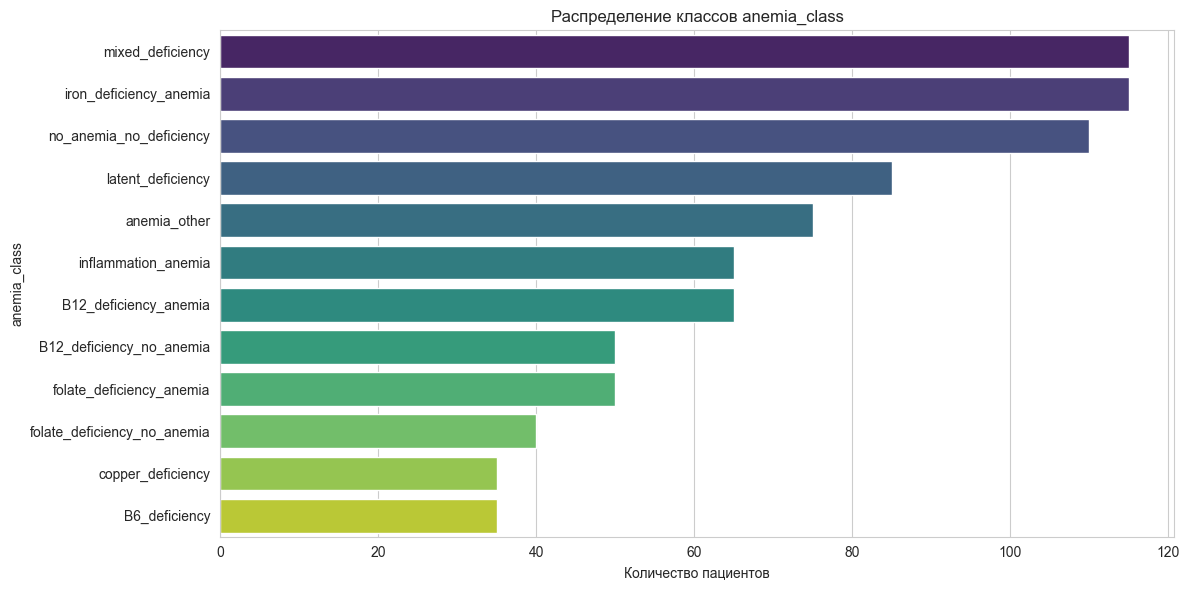

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='anemia_class',
              order=df['anemia_class'].value_counts().index,
              palette='viridis')
plt.title('Распределение классов anemia_class')
plt.xlabel('Количество пациентов')
plt.tight_layout()
plt.show()

## Выводы EDA

### Данные
- 840 пациентов × 48 признаков
- 34 float, 10 int, 4 object
- Все таргеты заполнены → можно обучать ML

### Пропуски (критичные)
- copper: 85.2%
- ceruloplasmin: 84.4%
- vitamin_B6: 83.9%
- Ret_He: 73.1%
- sTfR, active_B12: 70%
- MMA: 67.6%
- homocysteine: 64.5%
- ferritin: 29.3%

### Классы (12)
| Класс | Кол-во |
|---|---|
| mixed_deficiency | 115 |
| iron_deficiency_anemia | 115 |
| no_anemia_no_def iciency | 110 |
| latent_deficiency | 85 |
| anemia_other | 75 |
| inflammation_anemia | 65 |
| B12_deficiency_anemia | 65 |
| B12_deficiency_no_anemia | 50 |
| folate_deficiency_anemia | 50 |
| folate_deficiency_no_anemia | 40 |
| copper_deficiency | 35 |
| B6_deficiency | 35 |

Дисбаланс: 3.3× (умеренный)

### Особенности
- CRP max = 180 (есть выраженное воспаление)
- ESR max = 113
- eGFR min = 18 (есть ХБП)
- 63% пациентов с анемией

### Стратегия
1. XGBoost/LightGBM (устойчивы к NaN)
2. Флаги пропуска для ключевых признаков
3. class_weight='balanced'
4. StratifiedKFold(5)
5. Метрика: macro F1
6. Ожидаемые сложности: copper_deficiency, B6_deficiency (редкие + пропущенные)